# HDR Computation Example: Copula Flow vs Analytical

This notebook demonstrates how to compute the Highest Density Region (HDR) using copula flows and compares the result to an analytical calculation for a bivariate Gaussian distribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from coppuccino.copula_flows import normalizing_flows_fit, sample_and_log_prob
from coppuccino.hdr import compute_hdr, evaluate_point_in_hdr

## 1. Generate Samples from a Bivariate Gaussian

We'll use a correlated bivariate Gaussian distribution as our test case, since we can compute its HDR analytically.

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Define a correlated bivariate Gaussian
mean = np.array([2.0, -1.0])
cov = np.array([[1.5, 0.8],
                [0.8, 1.0]])

# Generate samples
n_samples = 5000
samples = np.random.multivariate_normal(mean, cov, n_samples)

print(f"Generated {n_samples} samples from bivariate Gaussian")
print(f"Mean: {mean}")
print(f"Covariance:\n{cov}")

Generated 5000 samples from bivariate Gaussian
Mean: [ 2. -1.]
Covariance:
[[1.5 0.8]
 [0.8 1. ]]


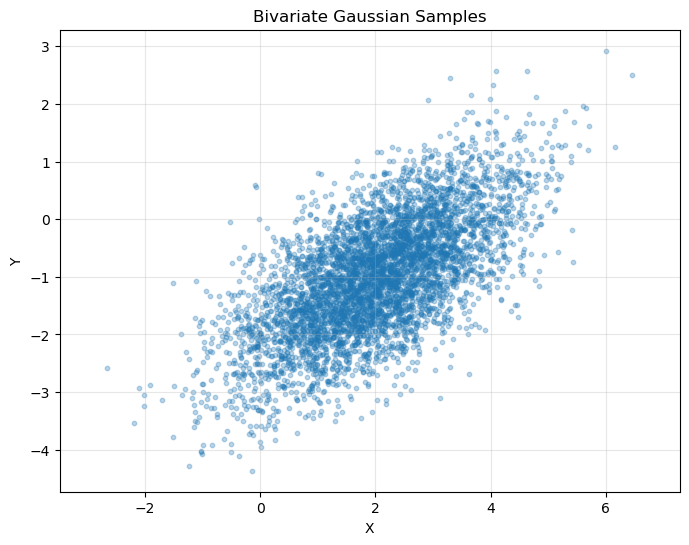

In [3]:
# Visualize the samples
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], alpha=0.3, s=10)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Bivariate Gaussian Samples')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

## 2. Fit Copula Flow to the Samples

In [4]:
# Fit normalizing flow to the samples
flow = normalizing_flows_fit(samples, rng_seed=42)
print("Flow fitted successfully!")

 14%|█▍        | 14/100 [00:04<00:25,  3.37it/s, train=2.55, val=2.57 (Max patience reached)]

Flow fitted successfully!


## 3. Compute HDR Using Copula Flow

In [5]:
# Compute 95% HDR using the flow
credible_level = 0.95
n_hdr_samples = 50000

# Generate samples and compute HDR threshold
flow_samples, flow_log_probs = sample_and_log_prob(flow, n_hdr_samples, rng_seed=999)
threshold_flow, mask = compute_hdr(flow, credible_level=credible_level, 
                                    samples=flow_samples, log_probs=flow_log_probs)

print(f"\nCopula Flow HDR (95%):")
print(f"  Log probability threshold: {threshold_flow:.4f}")
print(f"  Samples in HDR: {mask.sum()} / {len(mask)} = {mask.sum()/len(mask):.3f}")


Copula Flow HDR (95%):
  Log probability threshold: -4.6988
  Samples in HDR: 47500 / 50000 = 0.950


## 4. Compute Analytical HDR for Bivariate Gaussian

For a multivariate Gaussian, the HDR is an ellipse. The log probability threshold can be computed from the chi-square distribution.

In [6]:
# For a bivariate Gaussian, the Mahalanobis distance squared follows chi-square(2)
# The 95% HDR corresponds to chi2.ppf(0.95, df=2)
chi2_threshold = stats.chi2.ppf(credible_level, df=2)

# The analytical log probability threshold
# log p(x) = -0.5 * (k*log(2π) + log|Σ| + (x-μ)ᵀΣ⁻¹(x-μ))
k = len(mean)
sign, logdet = np.linalg.slogdet(cov)
threshold_analytical = -0.5 * (k * np.log(2 * np.pi) + logdet + chi2_threshold)

print(f"\nAnalytical HDR (95%):")
print(f"  Chi-square threshold: {chi2_threshold:.4f}")
print(f"  Log probability threshold: {threshold_analytical:.4f}")


Analytical HDR (95%):
  Chi-square threshold: 5.9915
  Log probability threshold: -4.7582


## 5. Verify Against True Distribution

We'll compute the log probabilities of our flow samples under the true Gaussian and check what fraction falls within the analytical HDR.

In [7]:
# Create the true distribution
true_dist = stats.multivariate_normal(mean, cov)

# Compute log probabilities under true distribution
true_log_probs = true_dist.logpdf(flow_samples)

# Check how many samples fall in analytical HDR
analytical_mask = true_log_probs >= threshold_analytical

print(f"\nVerification using true distribution:")
print(f"  Samples in analytical HDR: {analytical_mask.sum()} / {len(analytical_mask)} = {analytical_mask.sum()/len(analytical_mask):.3f}")
print(f"  Expected: {credible_level:.3f}")


Verification using true distribution:
  Samples in analytical HDR: 47187 / 50000 = 0.944
  Expected: 0.950


## 6. Compare Thresholds

In [8]:
print(f"\n{'='*60}")
print(f"COMPARISON OF HDR THRESHOLDS")
print(f"{'='*60}")
print(f"Analytical threshold:      {threshold_analytical:.6f}")
print(f"Flow threshold:            {threshold_flow:.6f}")
print(f"Absolute difference:       {abs(threshold_flow - threshold_analytical):.6f}")
print(f"Relative difference:       {abs(threshold_flow - threshold_analytical)/abs(threshold_analytical)*100:.2f}%")
print(f"{'='*60}")


COMPARISON OF HDR THRESHOLDS
Analytical threshold:      -4.758198
Flow threshold:            -4.698849
Absolute difference:       0.059349
Relative difference:       1.25%


## 7. Visualize the HDR Regions

In [ ]:
# Create a grid for visualization
x_min, x_max = flow_samples[:, 0].min() - 1, flow_samples[:, 0].max() + 1
y_min, y_max = flow_samples[:, 1].min() - 1, flow_samples[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Compute log probabilities on grid
from coppuccino.copula_flows import log_prob
grid_log_probs_flow = log_prob(flow, grid_points)
grid_log_probs_true = true_dist.logpdf(grid_points)

# Reshape for contour plotting
zz_flow = grid_log_probs_flow.reshape(xx.shape)
zz_true = grid_log_probs_true.reshape(xx.shape)

/var/folders/8d/436xvw6j6g13_xm6nrrvwv7c0000gn/T/ipykernel_34473/2285725448.py:28: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, zz_true, levels=[threshold_analytical], colors='blue',
/var/folders/8d/436xvw6j6g13_xm6nrrvwv7c0000gn/T/ipykernel_34473/2285725448.py:30: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, zz_flow, levels=[threshold_flow], colors='red',
/var/folders/8d/436xvw6j6g13_xm6nrrvwv7c0000gn/T/ipykernel_34473/2285725448.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


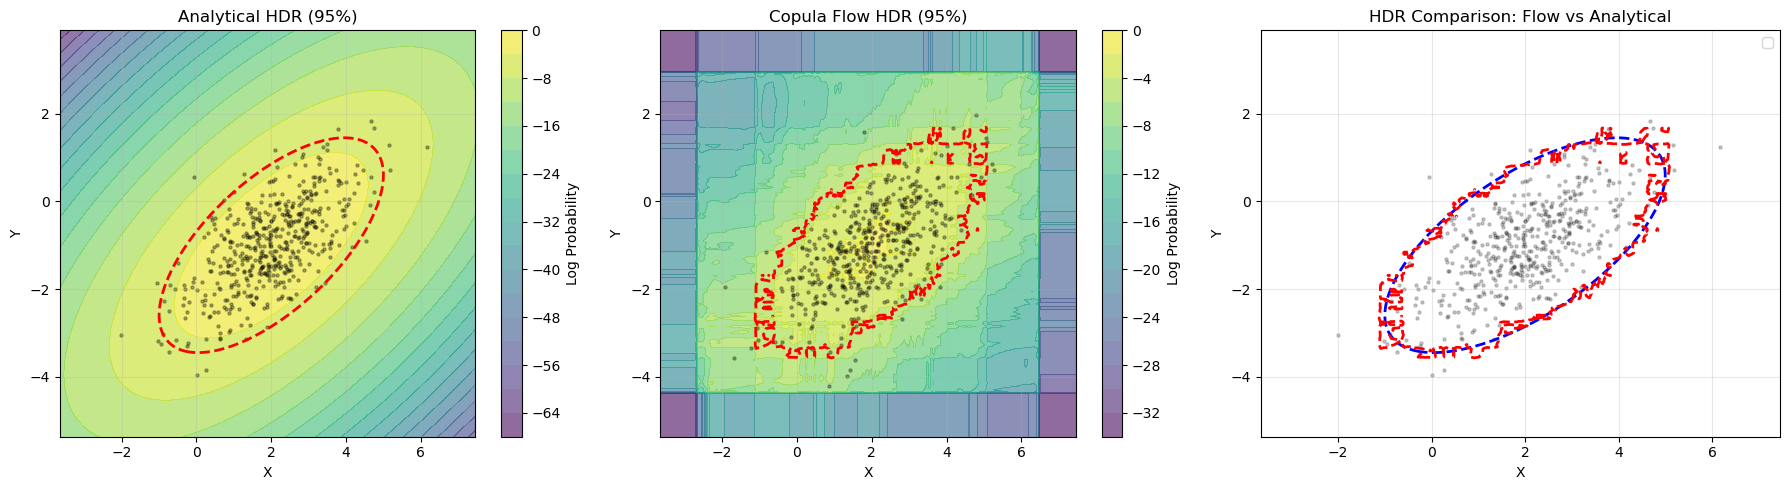

In [10]:
# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Analytical HDR
ax = axes[0]
contour = ax.contourf(xx, yy, zz_true, levels=20, cmap='viridis', alpha=0.6)
ax.contour(xx, yy, zz_true, levels=[threshold_analytical], colors='red', linewidths=2)
ax.scatter(samples[:500, 0], samples[:500, 1], alpha=0.3, s=5, c='black')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Analytical HDR (95%)')
ax.grid(True, alpha=0.3)
plt.colorbar(contour, ax=ax, label='Log Probability')

# Plot 2: Flow HDR
ax = axes[1]
contour = ax.contourf(xx, yy, zz_flow, levels=20, cmap='viridis', alpha=0.6)
ax.contour(xx, yy, zz_flow, levels=[threshold_flow], colors='red', linewidths=2)
ax.scatter(flow_samples[:500, 0], flow_samples[:500, 1], alpha=0.3, s=5, c='black')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Copula Flow HDR (95%)')
ax.grid(True, alpha=0.3)
plt.colorbar(contour, ax=ax, label='Log Probability')

# Plot 3: Overlay comparison
ax = axes[2]
ax.contour(xx, yy, zz_true, levels=[threshold_analytical], colors='blue', 
           linewidths=2, linestyles='--', label='Analytical')
ax.contour(xx, yy, zz_flow, levels=[threshold_flow], colors='red', 
           linewidths=2, label='Flow')
ax.scatter(samples[:500, 0], samples[:500, 1], alpha=0.2, s=5, c='black')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('HDR Comparison: Flow vs Analytical')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Test Point Evaluation

We can also evaluate whether specific points are inside the HDR.

In [11]:
# Test some points
test_points = np.array([
    [2.0, -1.0],   # Mean - should be in HDR
    [0.0, 0.0],    # Off center - may or may not be in HDR
    [5.0, 2.0],    # Far from mean - likely outside HDR
])

in_hdr_flow = evaluate_point_in_hdr(flow, test_points, credible_level=credible_level, 
                                     threshold=threshold_flow)

# Also check analytically
test_log_probs = true_dist.logpdf(test_points)
in_hdr_analytical = test_log_probs >= threshold_analytical

print("\nPoint Evaluation:")
print(f"{'Point':<20} {'Flow HDR':<15} {'Analytical HDR':<15} {'Match'}")
print("-" * 60)
for i, point in enumerate(test_points):
    match = "✓" if in_hdr_flow[i] == in_hdr_analytical[i] else "✗"
    print(f"{str(point):<20} {str(in_hdr_flow[i]):<15} {str(in_hdr_analytical[i]):<15} {match}")


Point Evaluation:
Point                Flow HDR        Analytical HDR  Match
------------------------------------------------------------
[ 2. -1.]            True            True            ✓
[0. 0.]              False           False           ✓
[5. 2.]              False           False           ✓


## Summary

This notebook demonstrated:
1. Fitting a copula flow to samples from a bivariate Gaussian
2. Computing the 95% HDR using the copula flow
3. Computing the analytical HDR for the same distribution
4. Comparing the two approaches

The copula flow approach provides a close approximation to the analytical HDR, and can be applied to any distribution represented by samples, even when no analytical form exists.